This script will contain the chromatin tracing analysis for the primary GBM sample. 

The chromatin tracing has been run with `ecDNATracer` with default parameters. Unlike the ecDNA in GBM39, our probes only covered partially of the areas. Because of this, we did not enforce the circular assumption in tracing the ecDNA.

We will also focus on `AC/MES like GBM cells`.

Relevant figures can be found in Figure 6, Extended Data Figure 19, 20.

In [1]:
import numpy as np
import os
import pandas as pd

In [21]:
import sys
sys.path.append('../scripts/')
from ioMicroS6A import *
from ecDNATracer_HelperFunctions import *
from plot import *

# chromatin tracing: basic analysis

## load traces

In [2]:
import pickle
with open('D:\GBM39\ecDNATracer\gridSearch_traces_chromabb___Human_P4CC_EGFR_12_17_2024\human_allcellspossible__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)

In [3]:
tr_type = 'Xtraces_chrom_inter_148_149_151'

In [7]:
linear_traces, circ_traces_all = dic_linear_circ_by_type[tr_type]
linear_traces.shape, circ_traces_all.shape

((4314, 252, 6), (319079, 252, 6))

In [9]:
## subset to only cells that have endougenous chr7 identified
ufovcells= np.unique(np.nanmean(linear_traces[:,:, -1], axis = 1))
len(ufovcells)

3955

In [10]:
circ_traces = circ_traces_all[np.isin(np.nanmean(circ_traces_all[:,:, -1], axis = 1), ufovcells)]
circ_traces.shape

(31853, 252, 6)

In [11]:
del circ_traces_all

## subset to only cluster of interest

AC/MES like GBM cells are leiden cluster 4 and 5

In [23]:
istart = 3
iend = 125

In [31]:
start_mb = 54.9
end_mb = 55.5

In [13]:
df_meta = pd.read_csv(r'C:/GBM39/Human_P4CC_EGFR_12_17_2024/20251027_dcc3_cell_metadata_subset.csv')

In [14]:
df_meta['ifovcell'] = df_meta['cell_name'].apply(lambda x: int(x.split('_')[-1]))

In [15]:
ufovcells_all= np.unique(np.nanmean(linear_traces[:,:, -1], axis = 1))

df_cluster_big = df_meta[df_meta['ifovcell'].isin(ufovcells_all)]
df_cluster_big.shape

(3548, 7)

In [16]:
dic_ifovcell_leiden = dict(zip(df_cluster_big['ifovcell'], df_cluster_big['leiden']))
dic_leiden_ifovcell = {}
for cell in dic_ifovcell_leiden:
    leiden = dic_ifovcell_leiden[cell]
    if leiden in dic_leiden_ifovcell.keys():
        dic_leiden_ifovcell[leiden].append(cell)
    else:
        dic_leiden_ifovcell[leiden] = [cell]

In [27]:
acmes_linear_traces = linear_traces[np.isin(np.nanmean(linear_traces[:,:, -1], axis = 1),dic_leiden_ifovcell[4] + dic_leiden_ifovcell[5])]
acmes_circ_traces = circ_traces[np.isin(np.nanmean(circ_traces[:,:, -1], axis = 1),dic_leiden_ifovcell[4]+ dic_leiden_ifovcell[5])]
len(acmes_linear_traces), len(acmes_circ_traces)

(1311, 14484)

# comparison to HiC

In [28]:
acmes_joint_traces = np.vstack([acmes_linear_traces, acmes_circ_traces])
acmes_joint_traces.shape

(15795, 252, 6)

In [29]:
acmes_joint_meddist = np.nanmedian(compute_med_dist_mat(acmes_joint_traces[:, istart:iend+1, :], contact_dist = None), axis = 0)
acmes_joint_meddist.shape

100%|█████████████████████████████████████████████████████████████████████████| 15795/15795 [00:01<00:00, 12549.08it/s]


(123, 123)

## plot joint matrix

Text(0.5, 1.0, 'AC/MES like GBM Median distance\n 1143 cells, 15795 traces')

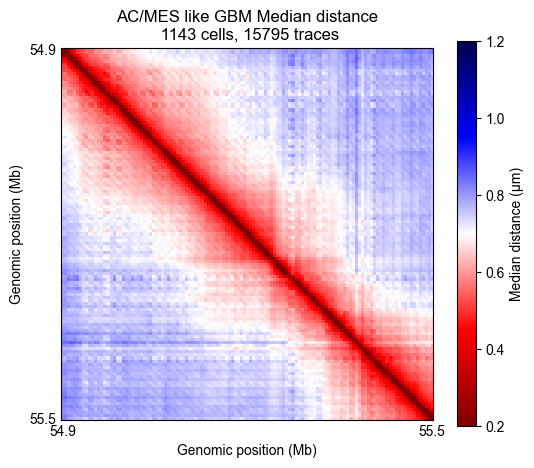

In [32]:
ntrs = len(acmes_joint_traces)
ncells = len(np.unique(np.nanmean(acmes_joint_traces[:,:,-1], axis = 1)))
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard

plt.rcParams['font.family'] = 'Arial'

# --- Data & colormap with NaNs as dark gray ---
M0 = acmes_joint_meddist.copy()
M0_smooth = cv2.blur(M0, (2, 2))

cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
import numpy as np
import matplotlib.pyplot as plt

N = M0_smooth.shape[0]
labels = np.arange(istart, iend + 1)          # length should be N
tick_step = 10                                 # change to taste
ticks = np.arange(0, N, tick_step)

fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
im = ax.imshow(M0_smooth, cmap=cmap, vmin=0.2, vmax=1.2,
               interpolation='nearest', rasterized=True)

# remove ticks completely
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (µm)')
ax.set_title(f'AC/MES like GBM Median distance\n {ncells} cells, {ntrs} traces')


# --- Save (rasterized artists embedded at 1200 dpi) ---

## droplet HiC

In [33]:
hic_mat = np.load(r'D:\GBM39\P4CC_HiC\LC649_merged_hg38_ecDNA_hic_balanced.npy')
hic_mat = hic_mat[istart:iend+1, istart:iend+1]
hic_mat.shape

(123, 123)

In [34]:
eps = 1e-6
L = np.log10(hic_mat + eps)
vmin = np.nanpercentile(L, 5)
vmax = np.nanpercentile(L, 99)
vmin,vmax

(-6.0, -1.5591398579270148)

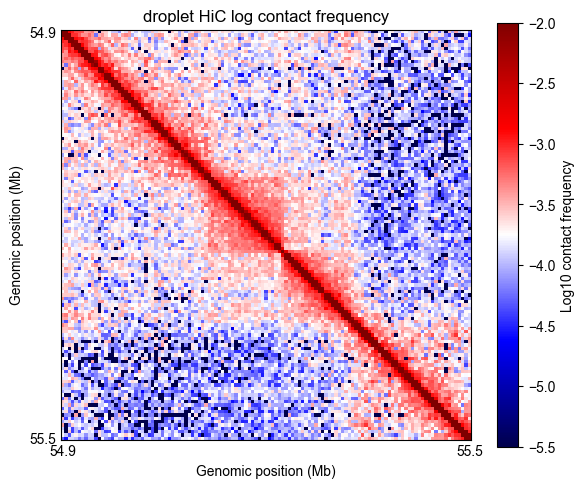

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard
plt.rcParams['font.family'] = 'Arial'



# --- Data & colormap with NaNs as dark gray ---
M0 = L.copy()
cmap = plt.cm.seismic.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(M0, cmap=cmap, vmin=-2, vmax=-5,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Log10 contact frequency')
ax.set_title(f'droplet HiC log contact frequency')

fig.tight_layout()

# --- Save (rasterized artists embedded at 1200 dpi) ---

## plot correlation: HiC vs. FISH

In [36]:
D_circ_contact = compute_med_dist_mat(acmes_joint_traces[:, istart:iend+1, :], contact_dist = None)
D_circ_contact.shape

100%|█████████████████████████████████████████████████████████████████████████| 15795/15795 [00:01<00:00, 12020.66it/s]


(15795, 123, 123)

In [37]:
D_circ_contact_freq =  np.mean(D_circ_contact < 0.25, axis=0)/ np.mean(D_circ_contact >= 0., axis=0)
D_circ_contact_freq.shape

(123, 123)

In [38]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.stats import pearsonr

def plot_hic_vs_spatial_log10(
    hic_mat: np.ndarray,
    spatial_mat: np.ndarray,
    vmax_dist: int = 120,
    plot_type: str = 'dist',              # 'dist' or anything else -> label tweak
    log: bool = True,                     # log10 axes (actually plotting log10 values)
    s: float = 5,                         # dot size
    alpha: float = 0.8,                   # dot alpha
    cmap: str = 'coolwarm',               # colormap for genomic distance
    svg_path = None,          # e.g., r"C:\path\plot.svg"
    dots_dpi: int = 300,                  # resolution for the rasterized dots
    clip_frac = (0, 1),                   # optional percentile clip on values (0..1, no clip)
    title = None
):
    """
    Scatter Hi-C vs spatial (upper triangle), color-coded by genomic distance.
    If log=True, plots log10(hic) vs log10(spatial) on linear axes and
    computes Pearson r in log10 space.

    Returns
    -------
    fig, ax, pearson_r
    """
    assert hic_mat.shape == spatial_mat.shape, "Hi-C and spatial matrices must have same shape"
    N = hic_mat.shape[0]

    # --- Upper triangle (exclude diagonal) ---
    iu, ju = np.triu_indices(N, k=1)
    hic_vals = hic_mat[iu, ju].astype(float)
    spatial_vals = spatial_mat[iu, ju].astype(float)
    genomic_dists = np.abs(iu - ju)

    # --- Optional percentile clipping on values (helps with extreme outliers) ---
    if clip_frac != (0, 1):
        lo_hic, hi_hic = np.nanpercentile(hic_vals, [100*clip_frac[0], 100*clip_frac[1]])
        lo_spa, hi_spa = np.nanpercentile(spatial_vals, [100*clip_frac[0], 100*clip_frac[1]])
        hic_vals = np.clip(hic_vals, lo_hic, hi_hic)
        spatial_vals = np.clip(spatial_vals, lo_spa, hi_spa)

    # --- Valid mask (and >0 if using log10) ---
    if log:
        valid = (
            np.isfinite(hic_vals) &
            np.isfinite(spatial_vals) &
            (hic_vals > 0) &
            (spatial_vals > 0)
        )
    else:
        valid = np.isfinite(hic_vals) & np.isfinite(spatial_vals)

    hic_vals = hic_vals[valid]
    spatial_vals = spatial_vals[valid]
    genomic_dists = genomic_dists[valid]

    # --- Transform for plotting + Pearson ---
    if log:
        x_plot = np.log10(hic_vals)
        y_plot = np.log10(spatial_vals)
        if len(x_plot) > 1:
            pearson_r, pearson_pval = pearsonr(x_plot, y_plot)
        else:
            pearson_r = np.nan
            pearson_pval = np.nan
    else:
        x_plot = hic_vals
        y_plot = spatial_vals
        if len(x_plot) > 1:
            pearson_r, pearson_pval = pearsonr(x_plot, y_plot)
        else:
            pearson_r = np.nan
            pearson_pval = np.nan

    print(f'pearson_pval = {pearson_pval}')
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6, 6))
    norm = Normalize(0, vmax_dist)
    sc = ax.scatter(
        x_plot, y_plot,
        c=np.clip(genomic_dists, 0, vmax_dist),
        cmap=cmap, norm=norm,
        s=s, alpha=alpha
    )

    # Rasterize ONLY the scatter dots in the SVG
    sc.set_rasterized(True)

    # axis labels
    ylab = 'pairwise spatial distance (µm)' if plot_type == 'dist' \
           else 'contact freq (<250 nm)'

    if log:
        ax.set_xlabel('log10 Droplet Hi-C interaction frequency')
        ax.set_ylabel(f'log10 Multimodal MERFISH\n{ylab}')
        base_title = 'Hi-C vs Spatial (log10–log10)'
    else:
        ax.set_xlabel('Droplet Hi-C interaction frequency')
        ax.set_ylabel(f'Multimodal MERFISH\n{ylab}')
        base_title = 'Hi-C vs Spatial'

    ttl = title if title is not None else f'{base_title}\n Pearson r = {pearson_r:.3f}, p = {pearson_pval}'
    ax.set_title(ttl)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Genomic distance (bins)')

    plt.tight_layout()

    # --- Save SVG with editable text, vectors for everything except dots ---
    if svg_path is not None:
        prev_font = mpl.rcParams.get('font.family', None)
        prev_svg = mpl.rcParams.get('svg.fonttype', None)
        try:
            mpl.rcParams['font.family'] = 'Arial'
            mpl.rcParams['svg.fonttype'] = 'none'  # keep text as text
            plt.savefig(svg_path, format='svg', dpi=dots_dpi, bbox_inches='tight')
        finally:
            if prev_font is not None:
                mpl.rcParams['font.family'] = prev_font
            if prev_svg is not None:
                mpl.rcParams['svg.fonttype'] = prev_svg
        # plt.close(fig)
    else:
        plt.show()

    return fig, ax, pearson_r



pearson_pval = 0.0


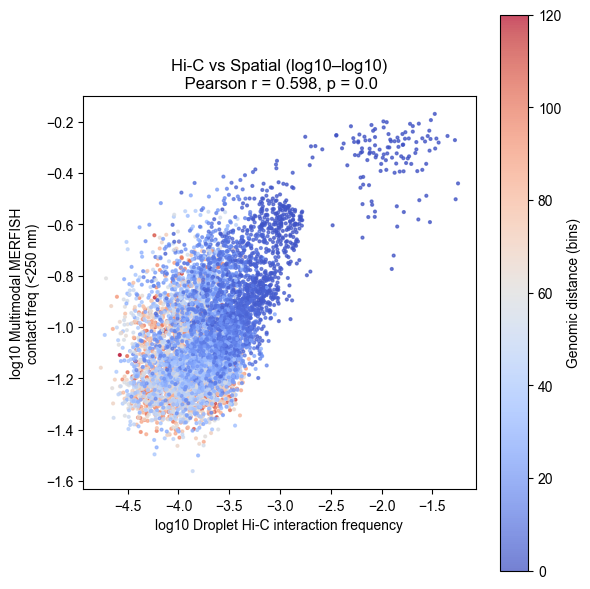

In [41]:
fig, ax, r = plot_hic_vs_spatial_log10(hic_mat = hic_mat, spatial_mat = D_circ_contact_freq, 
                    vmax_dist=120, plot_type = 'contact', log = True,
    # svg_path='C:/GBM39/manuscript_figures/extended_human_fig_tracing/plots/hic/humanP4CC_hic_vs_FISH_correlation.svg',
    dots_dpi=600, s=4, alpha=0.7)

# chr7 vs. ecDNA

## chr7 median distance matrix

In [42]:
acmes_linear_meddist = np.nanmedian(compute_med_dist_mat(acmes_linear_traces[:, istart:iend+1, :], contact_dist = None), axis = 0)
acmes_linear_meddist.shape

100%|███████████████████████████████████████████████████████████████████████████| 1311/1311 [00:00<00:00, 10562.85it/s]


(123, 123)

Text(0.5, 1.0, 'chr7 Median distance\n 1143 cells, 1311 traces')

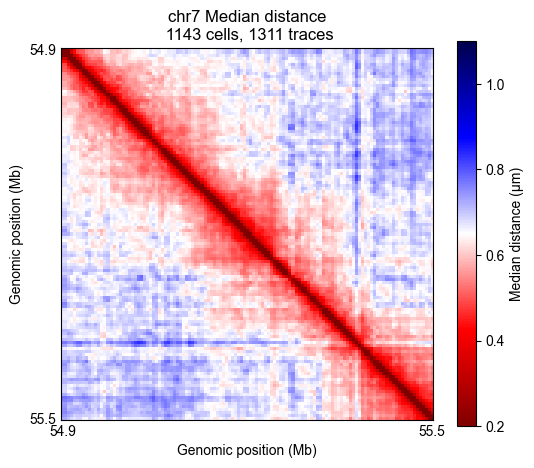

In [43]:
ntrs = len(acmes_linear_traces)
ncells = len(np.unique(np.nanmean(acmes_linear_traces[:,:,-1], axis = 1)))
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard

plt.rcParams['font.family'] = 'Arial'

# --- Data & colormap with NaNs as dark gray ---
M0 = acmes_linear_meddist.copy()
M0_smooth = cv2.blur(M0, (2, 2))

cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
import numpy as np
import matplotlib.pyplot as plt

N = M0_smooth.shape[0]
labels = np.arange(istart, iend + 1)          # length should be N
tick_step = 10                                 # change to taste
ticks = np.arange(0, N, tick_step)

fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
im = ax.imshow(M0_smooth, cmap=cmap, vmin=0.2, vmax=1.1,
               interpolation='nearest', rasterized=True)


# remove ticks completely
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")


# ----------------
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (µm)')
ax.set_title(f'chr7 Median distance\n {ncells} cells, {ntrs} traces')


# --- Save (rasterized artists embedded at 1200 dpi) ---

## ecDNA median distance matrix

This is the one in the main figure

In [44]:
acmes_circ_meddist = np.nanmedian(compute_med_dist_mat(acmes_circ_traces[:, istart:iend+1, :], contact_dist = None), axis = 0)
acmes_circ_meddist.shape

100%|█████████████████████████████████████████████████████████████████████████| 14484/14484 [00:01<00:00, 13651.67it/s]


(123, 123)

Text(0.5, 1.0, 'ecDNA Median distance\n 1143 cells, 14484 traces')

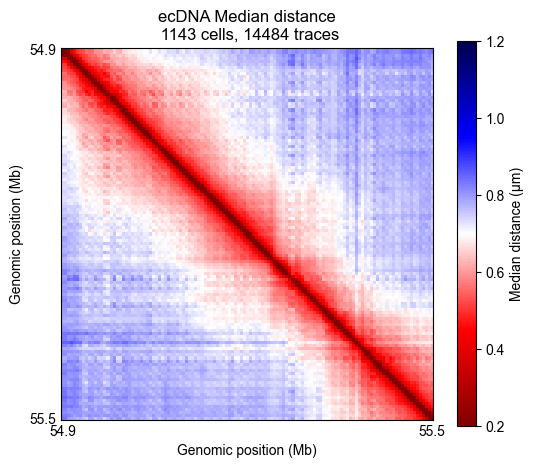

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt

ntrs = len(acmes_circ_traces)
ncells = len(np.unique(np.nanmean(acmes_circ_traces[:,:,-1], axis = 1)))

# --- Settings to keep text as real text in SVG (not paths) ---
plt.rcParams['svg.fonttype'] = 'none'          # keep text editable
if 'svg.image_noscale' in plt.rcParams:
    plt.rcParams['svg.image_noscale'] = True  # safe guard

plt.rcParams['font.family'] = 'Arial'

# --- Data & colormap with NaNs as dark gray ---
M0 = acmes_circ_meddist.copy()
M0_smooth = cv2.blur(M0, (2, 2))

cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
import numpy as np
import matplotlib.pyplot as plt

N = M0_smooth.shape[0]
labels = np.arange(istart, iend + 1)          # length should be N
tick_step = 10                                 # change to taste
ticks = np.arange(0, N, tick_step)

fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
im = ax.imshow(M0_smooth, cmap=cmap, vmin=0.2, vmax=1.2,
               interpolation='nearest', rasterized=True)

# remove ticks completely
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median distance (µm)')
ax.set_title(f'ecDNA Median distance\n {ncells} cells, {ntrs} traces')

## difference

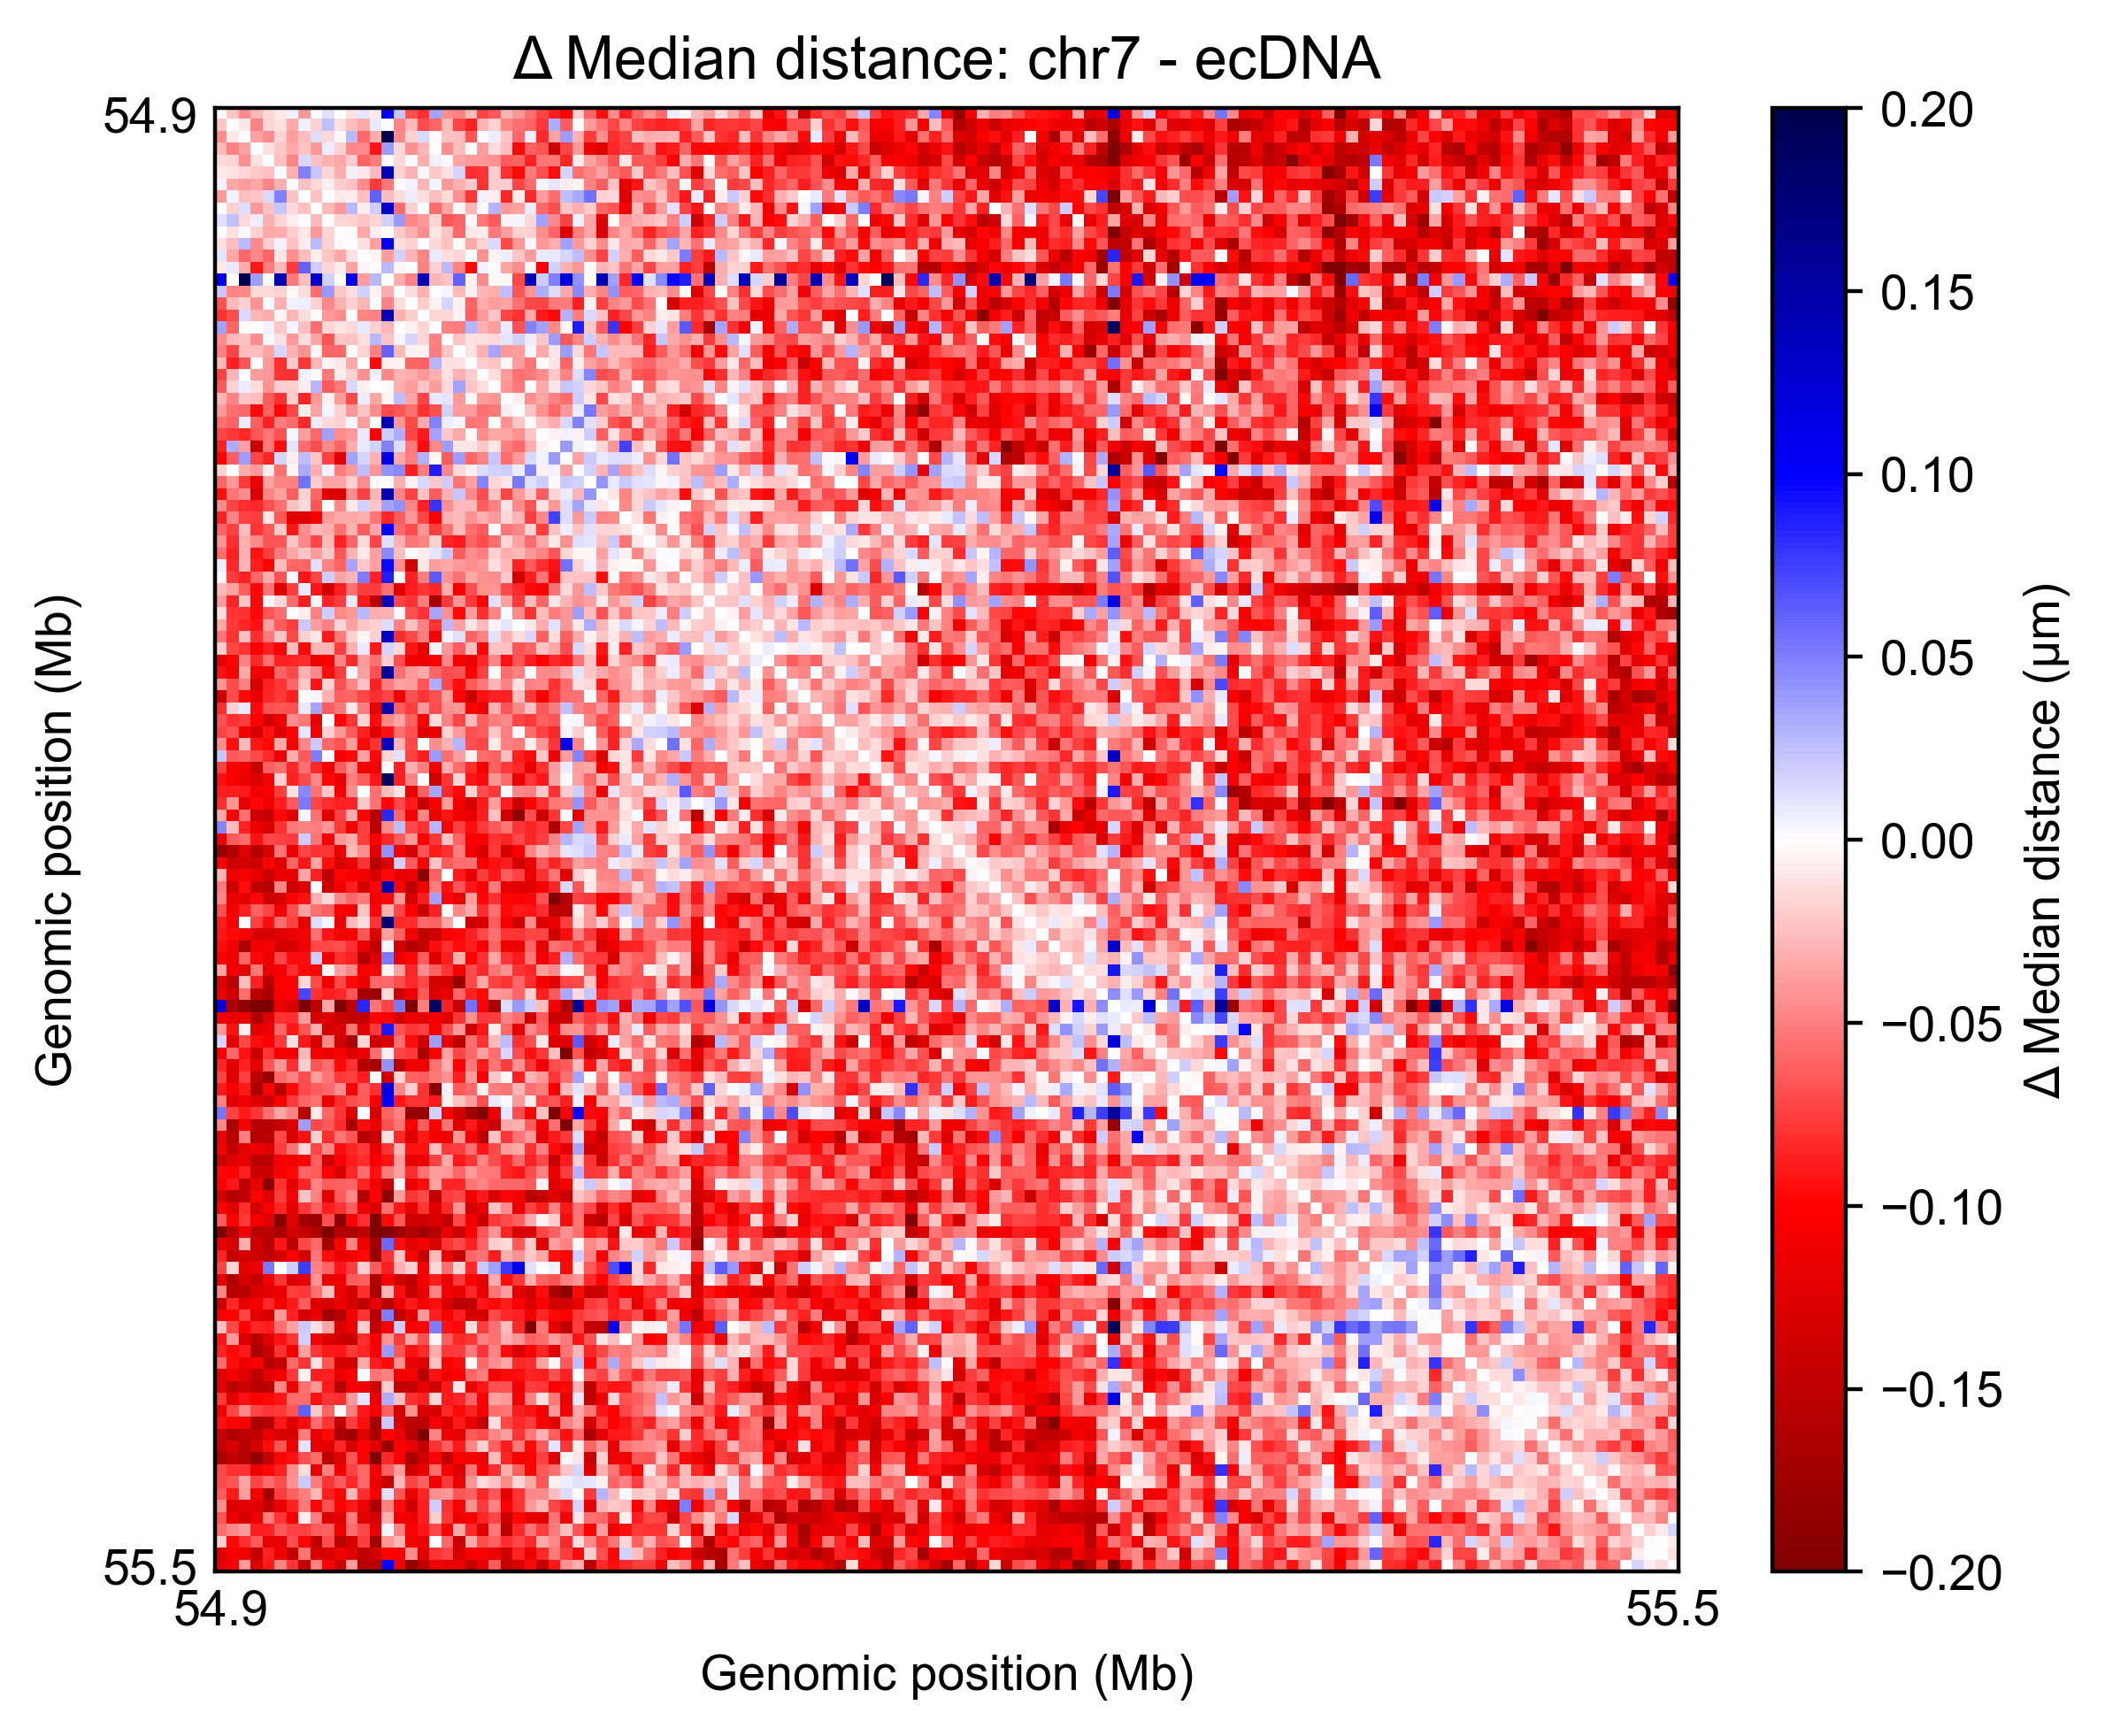

In [46]:
# --- Data & colormap with NaNs as dark gray ---
Mdiff = acmes_linear_meddist - acmes_circ_meddist
M0 = cv2.blur(Mdiff, (2,2))
cmap = plt.cm.seismic_r.copy()
cmap.set_bad(color='#808080')


# --- Plot ---
fig, ax = plt.subplots(figsize=(6.2, 5), dpi=400)  # dpi here doesn’t affect SVG vectors
im = ax.imshow(Mdiff, cmap=cmap, vmin=-0.2, vmax=0.2,
               interpolation='nearest', rasterized=True)  # <- only this gets rasterized
# remove ticks completely
ax.set_xticks([])
ax.set_yticks([])
# -----------------
# ----- ONLY show min/max axis labels -----
ax.set_xticks([0, N-1])
ax.set_yticks([0, N-1])

ax.set_xticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])
ax.set_yticklabels([f"{start_mb:.1f}", f"{end_mb:.1f}"])

# remove tick marks (very important)
ax.tick_params(length=0, width=0)

# ----- fix half-pixel heatmap shift -----
ax.set_xlim(-0.5, N-0.5)
ax.set_ylim(N-0.5, -0.5)
# labels
ax.set_xlabel("Genomic position (Mb)")
ax.set_ylabel("Genomic position (Mb)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Δ Median distance (µm)')

ax.set_title(f'Δ Median distance: chr7 - ecDNA')

fig.tight_layout()


## radius of gyration

In [47]:
def get_rgs(coords_um):
    coords_um = np.array(coords_um)
    coords_um -= np.nanmean(coords_um, axis=0)[np.newaxis, :]  # center of mass
    distances = np.linalg.norm(coords_um, axis=-1)
    rg = np.sqrt(np.nanmean(distances ** 2))
    return rg

In [48]:
lin_all_rgs = [get_rgs(tr[:,:3]) for tr in acmes_linear_traces[:, istart:iend+1, :] ]
circ_all_rgs = [get_rgs(tr[:,:3]) for tr in acmes_circ_traces[:, istart:iend+1, :] ]

In [49]:
df_plot_violin = pd.DataFrame(lin_all_rgs+ circ_all_rgs, columns = ['rgs'])
df_plot_violin['is_circular'] = [0] * len(lin_all_rgs) + [1] * len(circ_all_rgs)
df_plot_violin

,rgs,is_circular
0,0.915168,0
1,0.489849,0
2,0.407898,0
3,0.511280,0
4,0.316534,0
...,...,...
15790,0.312484,1
15791,0.401901,1
15792,0.248548,1
15793,0.363758,1


(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Radius of gyration:chr7 vs. ecDNA'}, ylabel='Radius of gyration (µm)'>,
             rgs  is_circular
 0      0.915168        False
 1      0.489849        False
 2      0.407898        False
 3      0.511280        False
 4      0.316534        False
 ...         ...          ...
 15790  0.312484         True
 15791  0.401901         True
 15792  0.248548         True
 15793  0.363758         True
 15794  0.415546         True
 
 [15795 rows x 2 columns],
 {'U': 7951373.5, 'p': 1.687913203296084e-22, 'q': None})

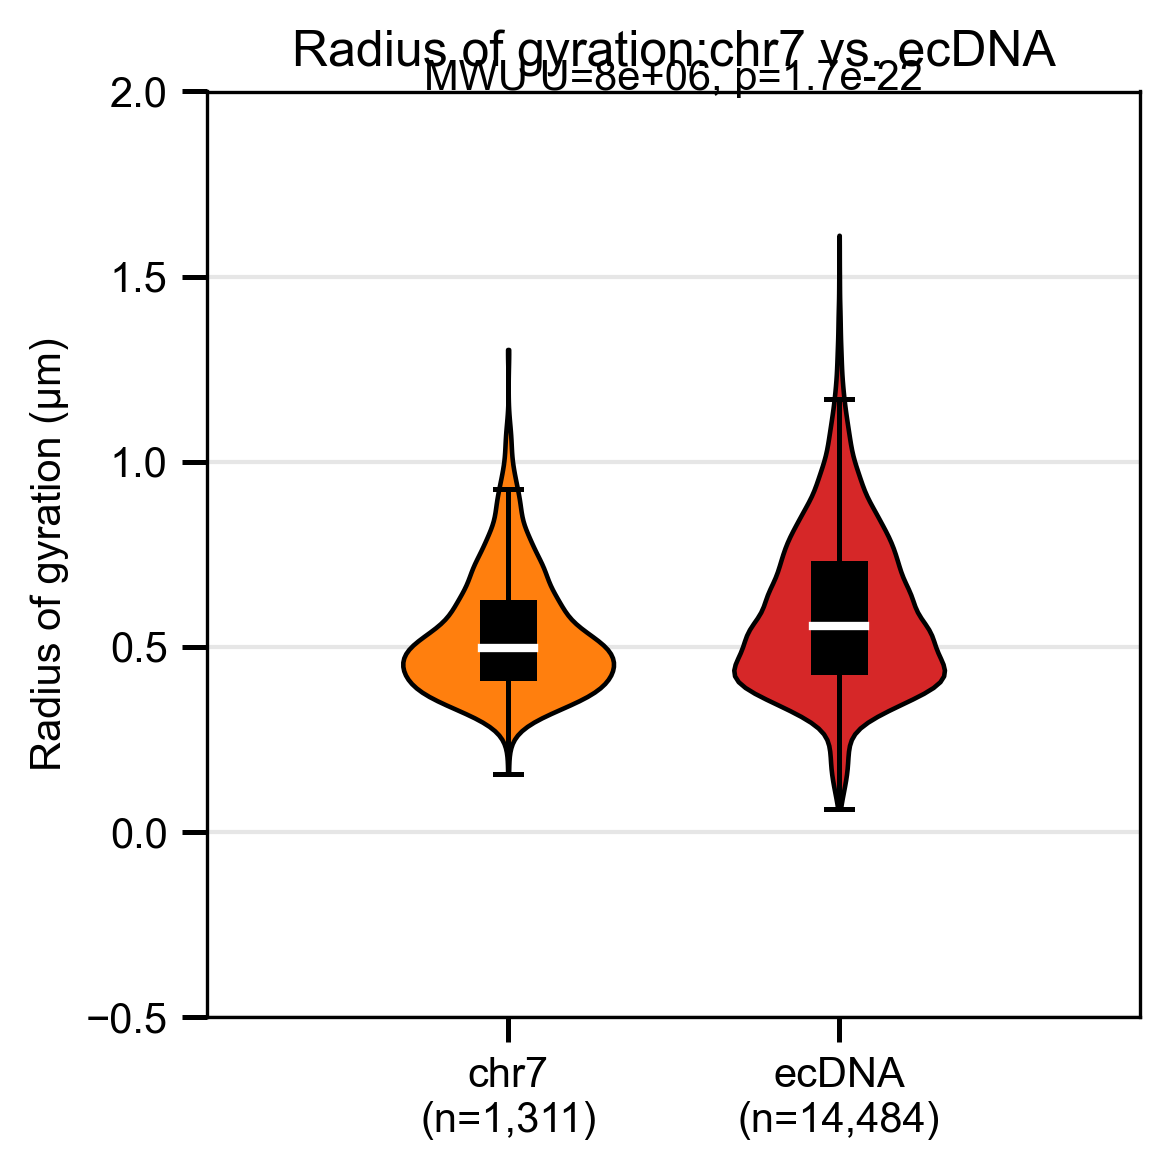

In [54]:
violin_two_groups_by_bool_mean_matplotlib(
    df=df_plot_violin,
    val_col='rgs',
    bool_col="is_circular",  # your boolean column
    order = (False, True),
    group_labels={True: "ecDNA", False: "chr7"},
    colors=("C1", "C3"),
    title="Radius of gyration:chr7 vs. ecDNA",
    y_label='Radius of gyration (µm)',
    do_mannwhitney=True,
    rasterize_violins=False,
    # save_svg = None,
    fig_size=(4, 4),#(4.6, 4),
    mannwhitney_alternative="two-sided", # "two-sided", "less"
    y_tick_step= 0.5,
    stats_fontsize=10,
    mean_dot_size = 50,
    x_gap=0.55,
    median_lw=2,
)

# intron analysis

# antibody analysis

# zone analysis